## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

## Device & Dataset Setup

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
train_boundary = 0.7

train_mnist = MNIST(root="./datasets", train=True, transform=transforms.ToTensor(), download=True)
test_mnist = MNIST(root="./datasets", train=False, transform=transforms.ToTensor(), download=True)

train_dataloader = DataLoader(train_mnist, batch_size=batch_size, shuffle=True, num_workers=1)
test_dataloader = DataLoader(test_mnist, batch_size=batch_size, shuffle=True, num_workers=1)

## Target Model (Undefended)
Todo: Upgrade the architecture

In [36]:
# Based on the TinyVGG architecture

class MNIST_classifier(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.block_1 = nn.Sequential(nn.Conv2d(
        in_channels=input_shape,
        out_channels=hidden_units,
        kernel_size=3,
        stride=1,
        padding=1
      ),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,
                 stride=2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(), # flattens tensors into a vector (e.g. [[1, 2], [3, 4]] -> [1, 2, 3, 4])
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x)
    return x

classifier = MNIST_classifier(input_shape=1, hidden_units=32, output_shape=10).to(device)

## Train the Target Model

In [37]:
epochs = 5
target_loss_fn = nn.CrossEntropyLoss()
target_optim_fn = torch.optim.Adam(params=classifier.parameters(), lr=0.0003)
model_folder = Path("models")
model_name = "target_model_statedict.pth"

def train_model(model, train_dataset, test_dataset, loss_fn : torch.nn, optim_fn : torch.optim, epochs : int, save_folder : Path, save_file_name : str, device : str):
  save_path = save_folder / save_file_name

  # If a state_dict exists, load it
  if save_path.exists():
    model.load_state_dict(torch.load(save_path, map_location=torch.device(device)))
    model = model.to(device)
  else:
    for epoch in range(epochs):
      model.train()
      train_loss, test_loss = 0, 0
      for j, (train_imgs, train_labels) in enumerate(tqdm(train_dataset, desc=f"Target Model Training | Epoch: {epoch + 1}/{epochs}", leave=True)):
        train_imgs, train_labels = train_imgs.to(device), train_labels.to(device)

        train_pred = model(train_imgs)

        loss = loss_fn(train_pred, train_labels)
        train_loss += loss.item()

        optim_fn.zero_grad()

        loss.backward()

        optim_fn.step()

      model.eval()
      with torch.inference_mode():
        for k, (test_imgs, test_labels) in enumerate(tqdm(test_dataset, desc=f"Target Model Testing | Epoch: {epoch + 1}/{epochs}", leave=True)):
          test_imgs, test_labels = test_imgs.to(device), test_labels.to(device)
          test_pred = model(test_imgs)

          loss = loss_fn(test_pred, test_labels)
          test_loss += loss.item()

      print(f"\nEpoch: {epoch + 1} | Train Loss: {train_loss / len(train_dataset)} | Test Loss: {test_loss / len(test_dataset)}\n")
    save_folder.mkdir(parents=True, exist_ok=True)
    torch.save(obj=model.state_dict(), f=save_path)

train_model(classifier, train_dataloader, test_dataloader, target_loss_fn, target_optim_fn, epochs, model_folder, model_name, device)

Target Model Training | Epoch: 1/5: 100%|██████████| 1875/1875 [00:16<00:00, 113.73it/s]
Target Model Testing | Epoch: 1/5: 100%|██████████| 313/313 [00:02<00:00, 153.39it/s]



Epoch: 1 | Train Loss: 0.23130996883238356 | Test Loss: 0.05811824711982887



Target Model Training | Epoch: 2/5: 100%|██████████| 1875/1875 [00:15<00:00, 117.82it/s]
Target Model Testing | Epoch: 2/5: 100%|██████████| 313/313 [00:02<00:00, 150.30it/s]



Epoch: 2 | Train Loss: 0.0632612260527288 | Test Loss: 0.04191763250428005



Target Model Training | Epoch: 3/5: 100%|██████████| 1875/1875 [00:15<00:00, 117.81it/s]
Target Model Testing | Epoch: 3/5: 100%|██████████| 313/313 [00:02<00:00, 131.88it/s]



Epoch: 3 | Train Loss: 0.04568740952713415 | Test Loss: 0.03363947317520448



Target Model Training | Epoch: 4/5: 100%|██████████| 1875/1875 [00:16<00:00, 113.74it/s]
Target Model Testing | Epoch: 4/5: 100%|██████████| 313/313 [00:02<00:00, 145.48it/s]



Epoch: 4 | Train Loss: 0.03623235698943026 | Test Loss: 0.039339434809349746



Target Model Training | Epoch: 5/5: 100%|██████████| 1875/1875 [00:15<00:00, 118.40it/s]
Target Model Testing | Epoch: 5/5: 100%|██████████| 313/313 [00:02<00:00, 140.64it/s]


Epoch: 5 | Train Loss: 0.02941587282564336 | Test Loss: 0.025511454754578677



## Vanilla AdvGAN

In [38]:
# Modified from GeeksForGeeks's Vanilla GAN Implementation:
# https://www.geeksforgeeks.org/deep-learning/generative-adversarial-network-gan/$0
# Originally, the VanillaGAN was made to generate images based on noise, for the CIFAR dataset.
# I updated its input dimensions and edited its generator to produce perturbations instead of images.

# This implementation treats ouputs of 1 as real and outputs of 0 as fake.
class Discriminator(nn.Module):
  def __init__(self, image_channels):
    super(Discriminator, self).__init__()

    self.image_channels = image_channels

    self.layer1 = nn.Sequential( # [batch_size=1, 1, 28, 28] -> [1, 32, 14, 14]
      nn.Conv2d(image_channels, 32, kernel_size=3, stride=2, padding=1),
      nn.LeakyReLU(0.2),
      nn.Dropout(0.25)
    )

    self.layer2 = nn.Sequential( # [1, 32, 14, 14] -> [1, 64, 7, 7]
      nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
    )

    self.layer3 = nn.Sequential( # [1, 64, 7, 7] -> [1, 64, 8, 8]
      nn.ZeroPad2d((0, 1, 0, 1)),
      nn.BatchNorm2d(64, momentum=0.82),
      nn.LeakyReLU(0.25),
      nn.Dropout(0.25)
    )

    self.layer4 = nn.Sequential( # [1, 64, 8, 8] --> [1, 128, 4, 4]
      nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
      nn.BatchNorm2d(128, momentum=0.82),
      nn.LeakyReLU(0.2),
      nn.Dropout(0.25),
    )

    self.layer5 = nn.Sequential( # [1, 128, 4, 4] -> [1, 256, 4, 4]
      nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
      nn.BatchNorm2d(256, momentum=0.8),
      nn.LeakyReLU(0.25),
      nn.Dropout(0.25)
    )

    self.layer6 = nn.Sequential( # [1, 256, 4, 4] -> [1, 4096]
      nn.Flatten()
    )

    self.layer7 = nn.Sequential( # [1, 4096] -> [1, 1]
      nn.Linear(4096, 1),
      nn.Sigmoid()
    )

  def forward(self, x):
    output = self.layer1(x)
    output = self.layer2(output)
    output = self.layer3(output)
    output = self.layer4(output)
    output = self.layer5(output)
    output = self.layer6(output)
    output = self.layer7(output)
    return output

class Generator(nn.Module):
  def __init__(self, image_channels, hidden_units):
    super(Generator, self).__init__()

    self.image_channels = image_channels
    self.hidden_units = hidden_units

    self.block1 = nn.Sequential(
      nn.Conv2d(image_channels, hidden_units, kernel_size=3, padding=1),  # [batch_size=1, 1, 28, 28] -> [1, 128, 28, 28]
      nn.BatchNorm2d(hidden_units, momentum=0.78),
      nn.ReLU()
    )

    self.block2 = nn.Sequential(
      nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),    # [1, 128, 28, 28] -> [1, 128, 28, 28]
      nn.BatchNorm2d(hidden_units, momentum=0.78),
      nn.ReLU()
    )

    self.block3 = nn.Sequential(
      nn.Conv2d(hidden_units, image_channels, kernel_size=3, padding=1),  # [1, 128, 28, 28] -> [1, 1, 28, 28]
      nn.Tanh()
    )

  def forward(self, x):
    perturbation = self.block1(x)
    perturbation = self.block2(perturbation)
    perturbation = self.block3(perturbation)
    return perturbation

vanilla_discriminator = Discriminator(1)
vanilla_generator = Generator(1, 128)

# test = torch.zeros(size=[1, 1, 28, 28])
# torch.round(vanilla_discriminator(test))

# test = None

# for i, (imgs, _) in enumerate(train_dataloader):
#   for img in imgs:
#     test = img.unsqueeze(dim=0)
#     break

# plt.figure(figsize=[4, 4])
# plt.imshow(test.squeeze())
# plt.figure(figsize=[4, 4])
# plt.imshow(vanilla_generator(test).squeeze().detach().numpy())

## Train the Vanilla AdvGan

AdvGAN Training | Epoch: 1/15: 100%|██████████| 1875/1875 [00:54<00:00, 34.10it/s]
AdvGAN Testing | Epoch: 1/15: 100%|██████████| 313/313 [00:04<00:00, 78.03it/s]



Epoch: 1
D_train_loss: 1.008 | G_train_loss: 0.439
D_test_loss: 1.006 | G_test_loss: 0.403
Target Model Accuracy (Train): 1.80%
Target Model Accuracy (Test): 0.31%




AdvGAN Training | Epoch: 2/15: 100%|██████████| 1875/1875 [00:54<00:00, 34.18it/s]
AdvGAN Testing | Epoch: 2/15: 100%|██████████| 313/313 [00:04<00:00, 64.25it/s]



Epoch: 2
D_train_loss: 1.006 | G_train_loss: 0.407
D_test_loss: 1.006 | G_test_loss: 0.406
Target Model Accuracy (Train): 0.40%
Target Model Accuracy (Test): 0.49%




AdvGAN Training | Epoch: 3/15: 100%|██████████| 1875/1875 [00:55<00:00, 34.08it/s]
AdvGAN Testing | Epoch: 3/15: 100%|██████████| 313/313 [00:03<00:00, 79.50it/s]


...


Epoch: 13
D_train_loss: 1.006 | G_train_loss: 0.402
D_test_loss: 1.011 | G_test_loss: 0.389
Target Model Accuracy (Train): 0.09%
Target Model Accuracy (Test): 0.47%




AdvGAN Training | Epoch: 14/15: 100%|██████████| 1875/1875 [00:55<00:00, 33.64it/s]
AdvGAN Testing | Epoch: 14/15: 100%|██████████| 313/313 [00:03<00:00, 79.07it/s]



Epoch: 14
D_train_loss: 1.006 | G_train_loss: 0.402
D_test_loss: 1.007 | G_test_loss: 0.399
Target Model Accuracy (Train): 0.07%
Target Model Accuracy (Test): 0.11%




AdvGAN Training | Epoch: 15/15: 100%|██████████| 1875/1875 [00:55<00:00, 33.96it/s]
AdvGAN Testing | Epoch: 15/15: 100%|██████████| 313/313 [00:03<00:00, 79.12it/s]



Epoch: 15
D_train_loss: 1.006 | G_train_loss: 0.402
D_test_loss: 1.016 | G_test_loss: 0.363
Target Model Accuracy (Train): 0.08%
Target Model Accuracy (Test): 0.15%




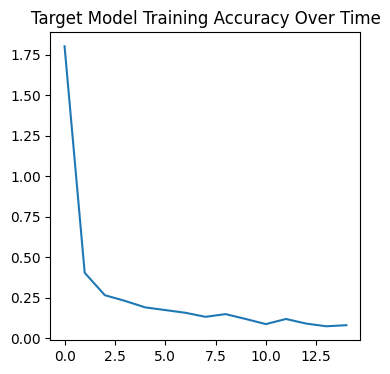

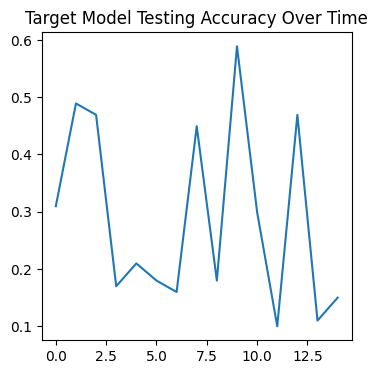

In [39]:
# The following function aims to calculate the loss of the generator using the loss formulas described in the original AdvGAN paper.
# Paper: https://arxiv.org/abs/1801.02610$0

class AdvGAN_Attack:
  def __init__(self, discriminator, generator, target_model, num_target_labels : int, target_loss_fn,
               D_loss_fn, D_optim_fn, G_optim_fn, # D = discriminator, G = generator; G_loss_fn uses get_generator_loss by default
               generator_loss_alpha : int | float, # alpha of the loss function as described in the AdvGAN paper
               generator_loss_beta : int | float, # beta of the loss function as described in the AdvGAN paper
               kappa : int | float, # minimum confidence in false prediction as described by C&W
               c : int | float, # maximum allowed perturbation
               batch_size : int | float, device):
    self.batch_size = batch_size
    self.device = device

    self.discriminator = discriminator.to(device)
    self.generator = generator.to(device)

    self.target_model = target_model.to(device)
    self.num_target_labels = num_target_labels
    self.target_loss_fn = target_loss_fn

    self.D_loss_fn = D_loss_fn
    self.D_optim_fn = D_optim_fn
    self.G_optim_fn = G_optim_fn
    self.generator_loss_alpha = generator_loss_alpha
    self.generator_loss_beta = generator_loss_beta
    self.kappa = kappa
    self.c = c

  def get_generator_loss(self, x : torch.tensor, # original images
                       y : torch.tensor, # labels for x
                       dx : torch.tensor, # the result of the discriminator when given x
                       gx : torch.tensor, # the result of the generator when given x
                       targeted : bool = False, target : torch.IntTensor | torch.LongTensor = None): # settings for targeted attacks and non-targeted attacks
    x, y, dx, gx = x.to(self.device), y.to(self.device), dx.to(self.device), gx.to(self.device)

    Lgan = torch.mean(torch.log(dx)) + torch.mean(torch.log(1 - self.discriminator(x + gx))) # torch.mean is used to calculate expected value

    # My implementation varies here: nn.CrossEntropyLoss only accepts model logits, so I use f(x + G(x)) instead of x + G(x)
    if targeted and target != None:
      Lf_adv = torch.mean(self.target_loss_fn(self.target_model(x + gx), target))
    else:
      # C&W untargeted loss
      logits = self.target_model(x + gx)
      batch_indices = torch.arange(logits.size(0), device=self.device)
      correct_logits = logits[batch_indices, y]

      masked_logits = logits.clone()
      masked_logits[batch_indices, y] = float('-inf')
      max_incorrect_logits, _ = torch.max(masked_logits, dim=1)

      Lf_adv = torch.mean(torch.maximum(correct_logits - max_incorrect_logits, torch.tensor(-1 * self.kappa)))

    # An alternate way of implementing max(0, ||G(x)|| - c)
    Lhinge = torch.mean(torch.clamp(torch.linalg.vector_norm(gx), min=0, max=self.c))

    total_loss = Lf_adv + self.generator_loss_alpha * Lgan + self.generator_loss_beta * Lhinge

    # MAE to find the difference between total_loss and 0, avoiding negative loss
    final_loss = F.l1_loss(total_loss, torch.zeros_like(total_loss), reduction="mean")
    return final_loss

  def train_or_test_advgan(self, img_batch, label_batch, train : bool = True,
                           targeted : bool = False, target : torch.IntTensor | torch.LongTensor = None):
    img_batch, label_batch = img_batch.to(self.device), label_batch.to(self.device)

    perturbation = self.generator(img_batch)
    adv_imgs = img_batch + perturbation
    adv_imgs = adv_imgs.to(self.device)

    # Optimize the discriminator
    # This implementation treats ouputs of 1 as real and outputs of 0 as fake.
    D_pred_real = self.discriminator(img_batch)
    D_pred_fake = self.discriminator(adv_imgs)

    D_loss_real = self.D_loss_fn(D_pred_real, torch.ones_like(D_pred_real))
    D_loss_fake = self.D_loss_fn(D_pred_fake, torch.zeros_like(D_pred_fake))

    if train:
      self.D_optim_fn.zero_grad()

      D_loss_real.backward()
      D_loss_fake.backward()

      self.D_optim_fn.step()

    D_loss = D_loss_real + D_loss_fake

    # Optimize the generator
    G_loss = self.get_generator_loss(img_batch, label_batch, self.discriminator(img_batch), self.generator(img_batch), targeted, target)

    if train:
      self.G_optim_fn.zero_grad()

      G_loss.backward()

      self.G_optim_fn.step()

    return D_loss.item(), G_loss.item()

  def train_advgan(self, train_dataloader, test_dataloader, targeted : bool = False,
                   train_target : torch.IntTensor | torch.LongTensor = None, # train_target should be a tensor containing all of the targets, corresponding to the training Dataloader
                   test_target : torch.IntTensor | torch.LongTensor = None,
                   epochs : int = 1):
    if targeted:
      train_target, test_target = train_target.to(self.device), test_target.to(self.device)

    train_accs = []
    test_accs = []

    self.target_model.eval()

    for epoch in range(epochs):
      # Training
      self.discriminator.train()
      self.generator.train()

      D_train_loss, G_train_loss, target_train_acc = 0, 0, 0

      for i, (imgs, labels) in enumerate(tqdm(train_dataloader, desc=f"AdvGAN Training | Epoch: {epoch + 1}/{epochs}")):
        imgs, labels = imgs.to(self.device), labels.to(self.device)

        target_subset = Subset(train_target, range(i * self.batch_size, (i + 1) * self.batch_size))
        D_loss, G_loss = self.train_or_test_advgan(imgs, labels, train=True, targeted=targeted, target=target_subset)

        D_train_loss += D_loss
        G_train_loss += G_loss

        attack_logits = self.target_model(imgs + self.generator(imgs))
        attack_pred = torch.argmax(torch.softmax(attack_logits, dim=1), dim=1)
        target_train_acc += (attack_pred == labels).sum().item()/len(attack_pred)

      # Testing
      self.discriminator.eval()
      self.generator.eval()
      with torch.inference_mode():
        D_test_loss, G_test_loss, target_test_acc = 0, 0, 0

        for j, (imgs, labels) in enumerate(tqdm(test_dataloader, desc=f"AdvGAN Testing | Epoch: {epoch + 1}/{epochs}")):
          imgs, labels = imgs.to(self.device), labels.to(self.device)

          target_subset = Subset(test_target, range(j * self.batch_size, (j + 1) * self.batch_size))
          D_loss, G_loss = self.train_or_test_advgan(imgs, labels, train=False, targeted=targeted, target=target_subset)

          D_test_loss += D_loss
          G_test_loss += G_loss

          # Attack success rate because loss isn't really a reliable indicator of performance
          attack_logits = self.target_model(imgs + self.generator(imgs))
          attack_pred = torch.argmax(torch.softmax(attack_logits, dim=1), dim=1)
          target_test_acc += (attack_pred == labels).sum().item()/len(attack_pred)

      print(f"\nEpoch: {epoch + 1}")
      print(f"D_train_loss: {D_train_loss/len(train_dataloader):.3f} | G_train_loss: {G_train_loss/len(train_dataloader):.3f}")
      print(f"D_test_loss: {D_test_loss/len(test_dataloader):.3f} | G_test_loss: {G_test_loss/len(test_dataloader):.3f}")

      train_acc = target_train_acc / len(train_dataloader) * 100
      train_accs.append(train_acc)
      test_acc = target_test_acc / len(test_dataloader) * 100
      test_accs.append(test_acc)
      print(f"Target Model Accuracy (Train): {train_acc:.2f}%")
      print(f"Target Model Accuracy (Test): {test_acc:.2f}%")
      print(f"\n")

    plt.figure(figsize=[4, 4])
    plt.plot(train_accs)
    plt.title("Target Model Training Accuracy Over Time")

    plt.figure(figsize=[4, 4])
    plt.plot(test_accs)
    plt.title("Target Model Testing Accuracy Over Time")

vanilla_AdvGAN = AdvGAN_Attack(vanilla_discriminator, vanilla_generator, classifier, 10, nn.CrossEntropyLoss(reduction="mean"), nn.BCEWithLogitsLoss(reduction="mean"), torch.optim.Adam(params=vanilla_discriminator.parameters(), lr=0.0003), torch.optim.Adam(params=vanilla_generator.parameters(), lr=0.0003),
                               generator_loss_alpha=1.0, generator_loss_beta=1.0, kappa=0.1, c=0.5, batch_size=32, device=device)
vanilla_AdvGAN.train_advgan(train_dataloader, test_dataloader,
                            epochs=15)